In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.utils.prune as prune
# import matplotlib.pyplot as plt
# from torch.utils.data import DataLoader, TensorDataset

# # 1. Create a simple model
# class SimpleModel(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.fc1 = nn.Linear(20, 50)
#         self.fc2 = nn.Linear(50, 10)
#         self.fc3 = nn.Linear(10, 2)
    
#     def forward(self, x):
#         x = torch.relu(self.fc1(x))
#         x = torch.relu(self.fc2(x))
#         return self.fc3(x)

# # 2. Initialize model and dummy dataset
# model = SimpleModel()
# print("Original model created")

# X = torch.randn(100, 20)
# y = torch.randn(100, 2)
# dataset = TensorDataset(X, y)
# loader = DataLoader(dataset, batch_size=10)

# # 3. LN Structured Pruning
# def apply_ln_pruning(model, amount=0.3, n=2, dim=0):
#     """Apply LN structured pruning to all Linear layers"""
#     print("\nApplying LN structured pruning...")
#     for name, module in model.named_modules():
#         if isinstance(module, nn.Linear):
#             prune.ln_structured(module, name="weight", amount=amount, n=n, dim=dim)
#             print(f"Pruned {name} | Amount: {amount}, Norm: L{n}, Dim: {dim}")
#     return model

# # 4. Sparsity info
# def print_structured_sparsity(model):
#     print("\nStructured Sparsity Statistics:")
#     for name, module in model.named_modules():
#         if isinstance(module, nn.Linear):
#             zero_rows = torch.sum(torch.all(module.weight == 0, dim=1)).item()
#             total_rows = module.weight.size(0)
#             print(f"{name}: {zero_rows}/{total_rows} rows (neurons) pruned ({100 * zero_rows/total_rows:.1f}%)")

# # 5. Visualize pruned weights for a layer
# def plot_weights(model, layer_name):
#     for name, module in model.named_modules():
#         if name == layer_name:
#             plt.figure(figsize=(10,4))
#             weights_pruned = module.weight.detach().numpy().flatten()
#             plt.hist(weights_pruned, bins=50, color='purple', alpha=0.7)
#             plt.title(f"{layer_name} - Pruned Weights Distribution")
#             plt.show()
#             break

# # 6. Fine-tuning (optional)
# def fine_tune(model, loader, epochs=3):
#     criterion = nn.MSELoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
#     print("\nFine-tuning...")
#     model.train()
#     for epoch in range(epochs):
#         for inputs, targets in loader:
#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, targets)
#             loss.backward()
#             optimizer.step()
#         print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
#     return model

# # 7. Remove pruning reparam and save model
# def remove_pruning(model):
#     for name, module in model.named_modules():
#         if isinstance(module, nn.Linear) and hasattr(module, 'weight_orig'):
#             prune.remove(module, 'weight')
#     return model

# # ----- Execution -----
# # pruned_model = apply_ln_pruning(model, amount=0.3, n=2, dim=0)
# # print_structured_sparsity(pruned_model)
# # plot_weights(pruned_model, "fc1")

# # pruned_model = fine_tune(pruned_model, loader)

# # final_model = remove_pruning(pruned_model)
# # torch.save({
# #     'model_state_dict': final_model.state_dict(),
# #     'pruning_metadata': {
# #         'method': 'LN Structured',
# #         'amount': 0.3,
# #         'norm': 'L2',
# #         'dim': 0,
# #         'layers': ['fc1', 'fc2', 'fc3']
# #     }
# # }, "ln_pruned_model.pth")

# # print("\nFinal LN-pruned model saved as 'ln_pruned_model.pth'")


L1 Structured Pruning

Original model created
Loaded model from checkpoint_model2_exp19

Applying LN structured pruning...
Pruned fc1 | Amount: 0.3, Norm: L2, Dim: 0
Pruned fc2 | Amount: 0.3, Norm: L2, Dim: 0
Pruned fc3 | Amount: 0.3, Norm: L2, Dim: 0

Structured Sparsity Statistics:
fc1: 15/50 rows (neurons) pruned (30.0%)
fc2: 3/10 rows (neurons) pruned (30.0%)
fc3: 1/2 rows (neurons) pruned (50.0%)


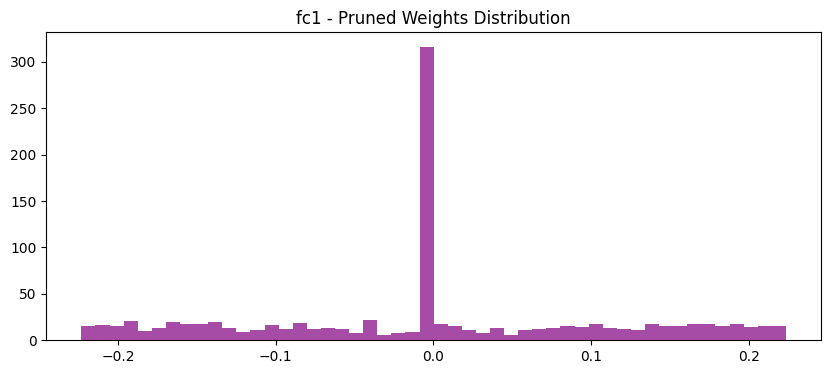


Fine-tuning...
Epoch 1, Loss: 0.6988
Epoch 2, Loss: 0.6947
Epoch 3, Loss: 0.6909

✅ Final pruned model saved as 'pruned_checkpoint_model2_exp19.pth'


In [ ]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
import os
from torch.utils.data import DataLoader, TensorDataset

# 1. Create a simple model
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20, 50)
        self.fc2 = nn.Linear(50, 10)
        self.fc3 = nn.Linear(10, 2)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# 2. Initialize model and dummy dataset
model = SimpleModel()
print("Original model created")

X = torch.randn(100, 20)
y = torch.randn(100, 2)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=10)

# 3. LN Structured Pruning
def apply_ln_pruning(model, amount=0.3, n=2, dim=0):
    """Apply LN structured pruning to all Linear layers"""
    print("\nApplying LN structured pruning...")
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            prune.ln_structured(module, name="weight", amount=amount, n=n, dim=dim)
            print(f"Pruned {name} | Amount: {amount}, Norm: L{n}, Dim: {dim}")
    return model

# 4. Sparsity info
def print_structured_sparsity(model):
    print("\nStructured Sparsity Statistics:")
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            zero_rows = torch.sum(torch.all(module.weight == 0, dim=1)).item()
            total_rows = module.weight.size(0)
            print(f"{name}: {zero_rows}/{total_rows} rows (neurons) pruned ({100 * zero_rows/total_rows:.1f}%)")

# 5. Visualize pruned weights for a layer
def plot_weights(model, layer_name):
    for name, module in model.named_modules():
        if name == layer_name:
            plt.figure(figsize=(10,4))
            weights_pruned = module.weight.detach().numpy().flatten()
            plt.hist(weights_pruned, bins=50, color='purple', alpha=0.7)
            plt.title(f"{layer_name} - Pruned Weights Distribution")
            plt.show()
            break

# 6. Fine-tuning (optional)
def fine_tune(model, loader, epochs=3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    print("\nFine-tuning...")
    model.train()
    for epoch in range(epochs):
        for inputs, targets in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
    return model

# 7. Remove pruning reparam and save model
def remove_pruning(model):
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and hasattr(module, 'weight_orig'):
            prune.remove(module, 'weight')
    return model

# Recreate the model architecture
device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint = torch.load('checkpoints/checkpoint_model2_exp19.pth', map_location=torch.device(device))
model = SimpleModel()
model.load_state_dict(checkpoint['model_state_dict'], strict=False)

print("Loaded model from checkpoint_model2_exp19")

# Now you can apply LN pruning as before
pruned_model = apply_ln_pruning(model, amount=0.3, n=2, dim=0)
print_structured_sparsity(pruned_model)
plot_weights(pruned_model, "fc1")

# Optional: Fine-tune if needed
pruned_model = fine_tune(pruned_model, loader)  # loader is your DataLoader, adjust as needed

# Step 1: Remove pruning reparametrizations (make pruning permanent)
final_model = remove_pruning(pruned_model)

# Step 2: Save the model
torch.save({
    'model_state_dict': final_model.state_dict(),
    'pruning_metadata': {
        'source_checkpoint': 'checkpoint_model2_exp19',
        'method': 'LN Structured',
        'amount': 0.3,
        'norm': 'L2',
        'dim': 0,
        'layers': ['fc1', 'fc2', 'fc3']
    }
}, "pruned_checkpoint_model2_exp19.pth")

print("\n✅ Final pruned model saved as 'pruned_checkpoint_model2_exp19.pth'")



Random Structured Pruning

✅ Loaded model from checkpoint_model2_exp19

Applying Random Structured Pruning...
Pruned fc1 | Amount: 0.3, Dim: 0
Pruned fc2 | Amount: 0.3, Dim: 0
Pruned fc3 | Amount: 0.3, Dim: 0

Structured Sparsity Statistics:
fc1: 15/50 rows (neurons) pruned (30.0%)
fc2: 3/10 rows (neurons) pruned (30.0%)
fc3: 1/2 rows (neurons) pruned (50.0%)


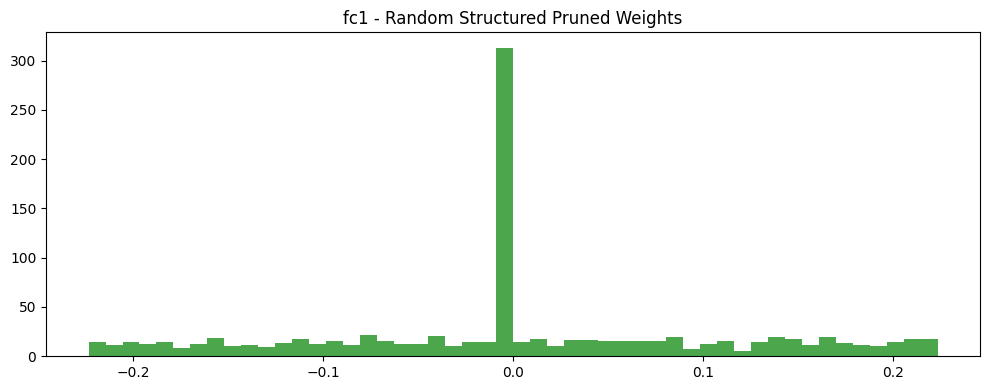


Fine-tuning...
Epoch 1, Loss: 1.3693
Epoch 2, Loss: 1.3515
Epoch 3, Loss: 1.3350

✅ Final pruned model saved as 'random_structured_pruned_checkpoint_model2_exp19.pth'


In [12]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# 1. Define the model architecture
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20, 50)
        self.fc2 = nn.Linear(50, 10)
        self.fc3 = nn.Linear(10, 2)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# 2. Load model from checkpoint
checkpoint = torch.load("checkpoints/checkpoint_model2_exp19.pth")  # Adjust path if needed
model = SimpleModel()
model.load_state_dict(checkpoint['model_state_dict'], strict=False)
print("✅ Loaded model from checkpoint_model2_exp19")

# 3. Dummy data loader (for fine-tuning)
X = torch.randn(100, 20)
y = torch.randn(100, 2)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=10)

# 4. Apply Random Structured Pruning
def apply_random_structured_pruning(model, amount=0.3, dim=0):
    """Apply Random Structured Pruning to all Linear layers"""
    print("\nApplying Random Structured Pruning...")
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            prune.random_structured(module, name="weight", amount=amount, dim=dim)
            print(f"Pruned {name} | Amount: {amount}, Dim: {dim}")
    return model

# 5. Check structured sparsity
def print_structured_sparsity(model):
    print("\nStructured Sparsity Statistics:")
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            zero_rows = torch.sum(torch.all(module.weight == 0, dim=1)).item()
            total_rows = module.weight.size(0)
            print(f"{name}: {zero_rows}/{total_rows} rows (neurons) pruned ({100 * zero_rows/total_rows:.1f}%)")

# 6. Visualize a layer’s pruned weights
def plot_weights(model, layer_name):
    for name, module in model.named_modules():
        if name == layer_name:
            plt.figure(figsize=(10,4))
            weights_pruned = module.weight.detach().numpy().flatten()
            plt.hist(weights_pruned, bins=50, color='green', alpha=0.7)
            plt.title(f"{layer_name} - Random Structured Pruned Weights")
            plt.tight_layout()
            plt.show()
            break

# 7. Fine-tune the model
def fine_tune(model, loader, epochs=3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    print("\nFine-tuning...")
    model.train()
    for epoch in range(epochs):
        for inputs, targets in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
    return model

# 8. Remove pruning reparam and save model
def remove_pruning(model):
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and hasattr(module, 'weight_orig'):
            prune.remove(module, 'weight')
    return model

# ---- Execute the full flow ----
model = apply_random_structured_pruning(model, amount=0.3, dim=0)  # prune rows (neurons)
print_structured_sparsity(model)
plot_weights(model, "fc1")

model = fine_tune(model, loader)
model = remove_pruning(model)

# Save final model with metadata
torch.save({
    'model_state_dict': model.state_dict(),
    'pruning_metadata': {
        'source_checkpoint': 'checkpoint_model2_exp19',
        'method': 'Random Structured',
        'amount': 0.3,
        'dim': 0,
        'layers': ['fc1', 'fc2', 'fc3']
    }
}, "random_structured_pruned_checkpoint_model2_exp19.pth")

print("\n✅ Final pruned model saved as 'random_structured_pruned_checkpoint_model2_exp19.pth'")


Global Unstructured

In [1]:
import torch
from torchvision import transforms
import torch.nn as nn
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm
import pickle
from functools import partial
from timesformer.models.vit import VisionTransformer
from datasets.kitti import KITTI
import numpy as np

# --- 1. Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float32)  # Ensure default is float32

# Load model config
with open("/Users/epheriami/Downloads/4B/Code/SYDE 673/P/tsformer/checkpoints/Exp3/args.pkl", 'rb') as f:
    args = pickle.load(f)
model_params = args["model_params"]

# KITTI dataset parameters
sequences = ['03']  # Your KITTI sequences
window_size = args["window_size"]
overlap = args["overlap"]

# --- 2. Model Initialization ---
model = VisionTransformer(
    img_size=model_params["image_size"],
    num_classes=model_params["num_classes"],
    patch_size=model_params["patch_size"],
    embed_dim=model_params["dim"],
    depth=model_params["depth"],
    num_heads=model_params["heads"],
    mlp_ratio=4,
    qkv_bias=True,
    norm_layer=partial(nn.LayerNorm, eps=1e-6),
    drop_rate=0.,
    attn_drop_rate=0.,
    drop_path_rate=0.1,
    num_frames=model_params["num_frames"],
    attention_type=model_params["attention_type"]
).to(device).float()  # Explicitly set to float32

# Load pretrained weights
checkpoint = torch.load("/Users/epheriami/Downloads/4B/Code/SYDE 673/P/data/models/baseline.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'], strict=False)

# --- 3. Data Preparation ---
def create_data_loaders(sequence, batch_size=4):
    """Create train/val loaders for a KITTI sequence"""
    full_dataset = KITTI(
        transform=preprocess,
        sequences=[sequence],
        window_size=window_size,
        overlap=overlap
    )
    
    # Split dataset (80% train, 20% val)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=2
    )
    
    return train_loader, val_loader

# --- 4. Pruning Utilities ---
def apply_global_pruning(model, amount):
    parameters_to_prune = [
        (module, 'weight') for module in model.modules() 
        if isinstance(module, nn.Linear)
    ]
    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount
    )
    print(f"Applied global pruning ({amount*100:.1f}% sparsity)")
    return model

def print_sparsity(model):
    print("\nLayer-wise sparsity:")
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            sparsity = 100. * float(torch.sum(module.weight == 0)) / module.weight.numel()
            print(f"{name:30s} {sparsity:.2f}%")

def remove_pruning(model):
    for module in model.modules():
        if isinstance(module, nn.Linear):
            prune.remove(module, 'weight')
    return model

# --- 5. Training/Evaluation ---
def evaluate(model, loader):
    model.eval()
    losses = []
    criterion = nn.MSELoss()
    
    with torch.no_grad(), tqdm(loader, unit="batch") as batchs:
        for images, gt in batchs:
            images = images.float().to(device)  # Convert to float32
            gt = gt.float().to(device)  # Convert to float32
            outputs = model(images)
            loss = criterion(outputs, gt)
            losses.append(loss.item())
            
    avg_loss = np.mean(losses)
    print(f"Validation Loss: {avg_loss:.4f}")
    return avg_loss

def fine_tune(model, loader, epochs=1, lr=1e-4):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        with tqdm(loader, unit="batch") as batchs:
            for images, gt in batchs:
                images = images.float().to(device)  # Convert to float32
                gt = gt.float().to(device)  # Convert to float32
                
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, gt)
                loss.backward()
                optimizer.step()
                
                batchs.set_postfix(loss=loss.item())

# --- 6. Gradual Pruning Pipeline ---
def gradual_pruning(model, train_loader, val_loader, target_amount=0.3, n_iterations=3):
    print("\nInitial evaluation:")
    initial_loss = evaluate(model, val_loader)
    
    for i in range(1, n_iterations+1):
        current_amount = target_amount * (i/n_iterations)
        
        print(f"\n--- Pruning Stage {i}/{n_iterations} ({current_amount*100:.1f}%) ---")
        model = apply_global_pruning(model, current_amount)
        print_sparsity(model)
        
        print("Fine-tuning...")
        fine_tune(model, train_loader, epochs=2)
        
        current_loss = evaluate(model, val_loader)
        print(f"Loss change: {initial_loss:.4f} → {current_loss:.4f}")

    return model

preprocess = transforms.Compose([
    transforms.Resize((model_params["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.34721234, 0.36705238, 0.36066107],
        std=[0.30737526, 0.31515116, 0.32020183]),
    transforms.ConvertImageDtype(torch.float32),  # Ensure float32 output
])

# --- 7. Main Execution ---
if __name__ == "__main__":
    # Select one sequence for pruning (or combine multiple)
    train_loader, val_loader = create_data_loaders(sequences[0])
    
    # Run gradual pruning
    pruned_model = gradual_pruning(model, train_loader, val_loader)
    
    # Final evaluation
    print("\nFinal evaluation on all sequences:")
    for seq in sequences:
        _, seq_loader = create_data_loaders(seq)
        print(f"\nSequence {seq}:")
        evaluate(pruned_model, seq_loader)
    
    # Save pruned model
    pruned_model = remove_pruning(pruned_model)
    torch.save({
        'model_state_dict': pruned_model.state_dict(),
        'pruning_metadata': {
            'method': 'Gradual Global Unstructured',
            'target_amount': 0.3,
            'iterations': 3,
            'val_loss': evaluate(pruned_model, val_loader)
        }
    }, "kitti_pruned_model.pth")

### Inference

In [39]:
import os

device = torch.device("cpu")

checkpoint_path = "/Users/epheriami/Downloads/4B/Code/SYDE 673/P/tsformer/checkpoints/Exp3"

with open(os.path.join(checkpoint_path, "args.pkl"), 'rb') as f:
    args = pickle.load(f)
f.close()
model_params = args["model_params"]
args["checkpoint_path"] = checkpoint_path

checkpoint = torch.load("/Users/epheriami/Downloads/4B/Code/SYDE 673/P/tsformer/static_quant_float64.pth", map_location=torch.device(device), weights_only=False)

model = VisionTransformer(img_size=model_params["image_size"],
                          num_classes=model_params["num_classes"],
                          patch_size=model_params["patch_size"],
                          embed_dim=model_params["dim"],
                          depth=model_params["depth"],
                          num_heads=model_params["heads"],
                          mlp_ratio=4,
                          qkv_bias=True,
                          norm_layer=partial(nn.LayerNorm, eps=1e-6),
                          drop_rate=0.,
                          attn_drop_rate=0.,
                          drop_path_rate=0.1,
                          num_frames=model_params["num_frames"],
                          attention_type=model_params["attention_type"])

model.load_state_dict(checkpoint['model_state_dict'])


<All keys matched successfully>

In [40]:
from datasets.kitti import KITTI
from torchvision import transforms
from tqdm import tqdm
import numpy as np

sequences = ["01", "04", "05", "06", "07", "10"]
# sequences = ["05", "06", "07", "10"]
device = "cpu"
checkpoint_name = "static_float64"

preprocess = transforms.Compose([
    transforms.Resize((model_params["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.34721234, 0.36705238, 0.36066107],
        std=[0.30737526, 0.31515116, 0.32020183]),
])

for sequence in sequences:
    # test dataloader
    dataset = KITTI(transform=preprocess, sequences=[sequence],
                    window_size=args["window_size"], overlap=args["overlap"])
    test_loader = torch.utils.data.DataLoader(dataset,
                                              batch_size=1,
                                              shuffle=False,
                                              )

    with tqdm(test_loader, unit="batch") as batchs:
        pred_poses = torch.zeros((1, args["window_size"] - 1, 6), device=device)
        batchs.set_description(f"Sequence {sequence}")
        for images, gt in batchs:

            with torch.no_grad():
                model.eval()
                model.training = False

                # predict pose
                pred_pose = model(images.float())
                pred_pose = torch.reshape(pred_pose, (args["window_size"] - 1, 6)).to(device)
                pred_pose = pred_pose.unsqueeze(dim=0)
                pred_poses = torch.concat((pred_poses, pred_pose), dim=0)

    # save as numpy array
    pred_poses = pred_poses[1:, :, :].cpu().detach().numpy()

    save_dir = os.path.join(args["checkpoint_path"], checkpoint_name)
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    np.save(os.path.join(save_dir, "pred_poses_{}.npy".format(sequence)), pred_poses)


Sequence 10: 100%|██████████| 400/400 [02:46<00:00,  2.41batch/s]


### 7DOF Transformation

In [23]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plot_results import save_trajectory, post_processing, KittiEvalOdom, align_trajectory_7dof, recover_trajectory_and_poses

gt_dir = "/Users/epheriami/Downloads/4B/Code/SYDE 673/P/data/poses"
pred_dir = "/Users/epheriami/Downloads/4B/Code/SYDE 673/P/tsformer/plotdir_npy"
output_dir = "/Users/epheriami/Downloads/4B/Code/SYDE 673/P/tsformer/checkpoints/Exp3/global_unstruct_pruning/output"

GOOGLE_BLUE = "#4285F4"
GOOGLE_ORANGE = "#FBBC04"
MODEL_COLORS = ["#FBBC04", "#FFA07A", "#8B9467", "#4CAF50", "#03A9F4"]

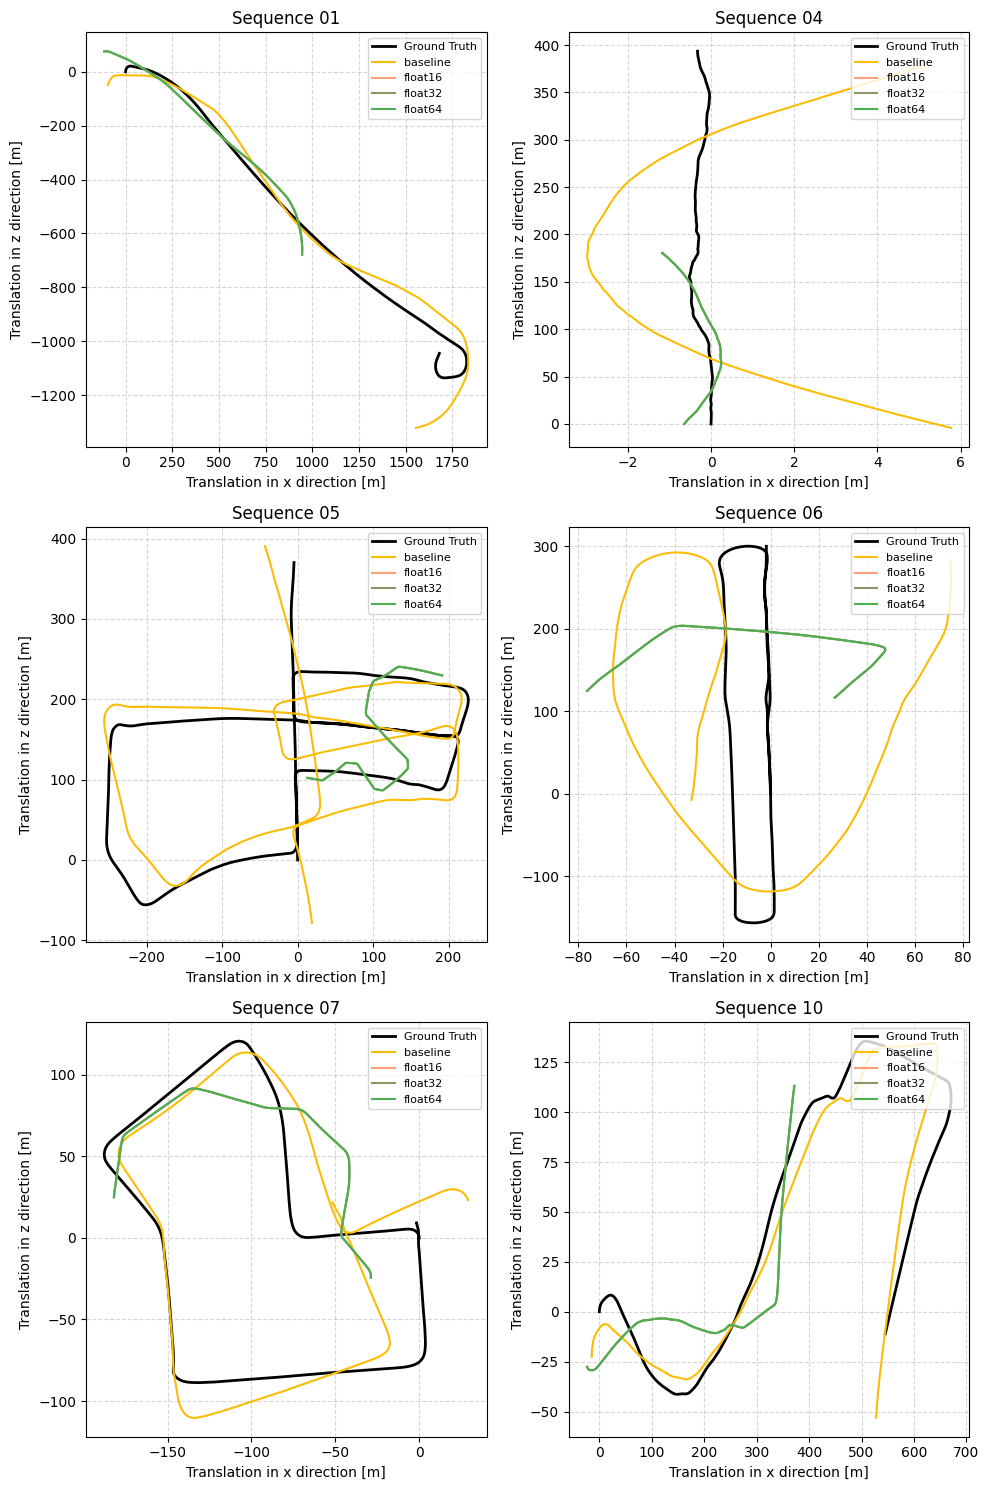

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Assuming other necessary functions and variables are defined (e.g., MODEL_COLORS, post_processing, align_trajectory_7dof, pred_dir)

# Initialize the figure with 3 rows and 2 columns of subplots
fig, axes = plt.subplots(3, 2, figsize=(10, 15))  # Adjust figure size as needed
plt.subplots_adjust(hspace=0.5, wspace=0.3)  # Adjust spacing between subplots

# models = ["baseline", "global_unstruc"]  # Define your models here
models = ["baseline", "float16", "float32", "float64"]  # Define your models here

# Loop through each sequence and plot in respective subplot
for idx, sequence in enumerate([1, 4, 5, 6, 7, 10]):
    seq = str(sequence).zfill(2)
    
    # Load ground truth poses
    kitti_eval = KittiEvalOdom()
    gt_path = os.path.join("/Users/epheriami/Downloads/4B/Code/SYDE 673/P/data/poses", f"{seq}.txt")
    gt_poses = kitti_eval.load_poses_from_txt(gt_path)
    gt_poses_list = [gt_poses[i] for i in sorted(gt_poses.keys())]
    
    # Select current subplot
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Plot ground truth trajectory
    gt_trajectory = np.array([pose[:3, 3] for pose in gt_poses_list])
    ax.plot(gt_trajectory[:, 0], gt_trajectory[:, 2], color="black", linewidth=2, label="Ground Truth")
    
    # Plot each model's trajectory
    for i, model in enumerate(models):
        pred_path = os.path.join(pred_dir, model, f"pred_poses_{seq}.npy")
        pred_poses = np.load(pred_path)
        # Apply post-processing and alignment
        pred_poses, _ = recover_trajectory_and_poses(post_processing(pred_poses, {"window_size": 3}))
        aligned_pred_poses = align_trajectory_7dof(pred_poses, gt_poses_list)
        pred_trajectory = [pose[:3, 3] for pose in aligned_pred_poses]
        ax.plot([x[0] for x in pred_trajectory], [z[2] for z in pred_trajectory],
                color=MODEL_COLORS[i], label=model)
    
    # Configure subplot appearance
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_title(f"Sequence {seq}", fontsize=12)
    ax.set_xlabel("Translation in x direction [m]", fontsize=10)
    ax.set_ylabel("Translation in z direction [m]", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()